## Mediapipe Hand Gesture Recognizer Model

The goal of this notebook is to try the hand geture recognizer model from mediapipe, in this case trained in the dataset of rock, papaer, scissors and see if it works in the howdy pipeline
https://ai.google.dev/edge/mediapipe/solutions/customization/gesture_recognizer

## Imports

In [5]:
%matplotlib inline
import os
import tensorflow as tf
assert tf.__version__.startswith('2')

from mediapipe_model_maker import gesture_recognizer

import matplotlib.pyplot as plt

## Import dataset

In [2]:
!wget https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/rps_data_sample.zip
!unzip rps_data_sample.zip
dataset_path = "rps_data_sample"

--2026-03-09 11:10:14--  https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/rps_data_sample.zip
Cargado certificado CA '/etc/ssl/certs/ca-certificates.crt'
Resolviendo storage.googleapis.com (storage.googleapis.com)... 172.217.171.59, 192.178.25.123, 216.58.215.155, ...
Conectando con storage.googleapis.com (storage.googleapis.com)[172.217.171.59]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 12332447 (12M) [application/zip]
Grabando a: ‘rps_data_sample.zip’

rps_data_sample.zip 100%[===================>]  11,76M  7,81MB/s    en 1,5s    

2026-03-09 11:10:16 (7,81 MB/s) - ‘rps_data_sample.zip’ guardado [12332447/12332447]

Archive:  rps_data_sample.zip
   creating: rps_data_sample/
   creating: rps_data_sample/paper/
   creating: rps_data_sample/rock/
   creating: rps_data_sample/scissors/
   creating: rps_data_sample/none/
  inflating: rps_data_sample/paper/77.jpg  
  inflating: rps_data_sample/paper/837.jpg  
  inflating: rps_data_sam

## See if labels are imported correclty

In [3]:
print(dataset_path)
labels = []
for i in os.listdir(dataset_path):
  if os.path.isdir(os.path.join(dataset_path, i)):
    labels.append(i)
print(labels)

rps_data_sample
['scissors', 'paper', 'rock', 'none']


## See samples for each label

Label: scissors
Label: paper
Label: rock
Label: none


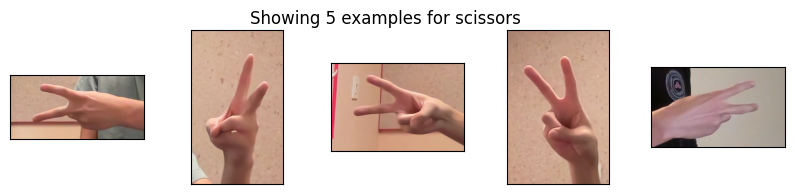

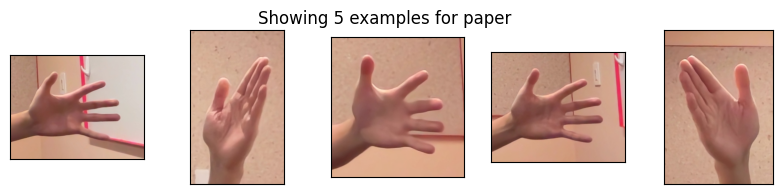

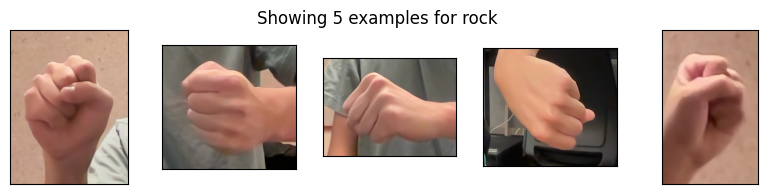

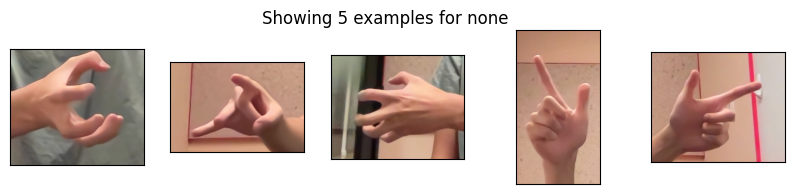

In [7]:
NUM_EXAMPLES = 5

for label in labels:
  print(f'Label: {label}')
  label_dir = os.path.join(dataset_path, label)
  example_filenames = os.listdir(label_dir)[:NUM_EXAMPLES]
  fig, axs = plt.subplots(1, NUM_EXAMPLES, figsize=(10,2))
  for i in range(NUM_EXAMPLES):
    axs[i].imshow(plt.imread(os.path.join(label_dir, example_filenames[i])))
    axs[i].get_xaxis().set_visible(False)
    axs[i].get_yaxis().set_visible(False)
  fig.suptitle(f'Showing {NUM_EXAMPLES} examples for {label}')

plt.show()

## Load datset

In [8]:
data = gesture_recognizer.Dataset.from_folder(
    dirname=dataset_path,
    hparams=gesture_recognizer.HandDataPreprocessingParams()
)
train_data, rest_data = data.split(0.8)
validation_data, test_data = rest_data.split(0.5)

INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/none/791.jpg


libEGL warning: DRI3 error: Could not get DRI3 device
libEGL warning: Ensure your X server supports DRI3 to get accelerated rendering
I0000 00:00:1773055256.947219   11432 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773055258.213383   11661 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.1-arch1.1), renderer: llvmpipe (LLVM 21.1.8, 256 bits)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773055258.293599   11663 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773055258.414206   11662 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/paper/838.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/paper/80.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/scissors/188.jpg


W0000 00:00:1773055259.623659   11662 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/paper/269.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/rock/441.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/paper/844.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/rock/891.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/rock/193.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/rock/536.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/scissors/630.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/rock/728.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/paper/146.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/tfg/notebooks/rps_data_sample/rock/851.jpg
INFO:tensorflow:Loading

INFO:tensorflow:Load valid hands with size: 473, num_label: 4, labels: none,paper,rock,scissors.


## Train model

In [9]:
hparams = gesture_recognizer.HParams(export_dir="rock_exported_model")
options = gesture_recognizer.GestureRecognizerOptions(hparams=hparams)
model = gesture_recognizer.GestureRecognizer.create(
    train_data=train_data,
    validation_data=validation_data,
    options=options
)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hand_embedding (InputLayer  [(None, 128)]             0         
 )                                                               
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 128)               0         
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 custom_gesture_recognizer_  (None, 4)                 516       
 out (Dense)                                                     
                                                             

INFO:tensorflow:Training the models...


Epoch 1/10
189/189 [==============================] - 31s 100ms/step - loss: 0.8596 - categorical_accuracy: 0.3995 - val_loss: 0.5403 - val_categorical_accuracy: 0.6170 - lr: 0.0010
Epoch 2/10
189/189 [==============================] - 102s 519ms/step - loss: 0.6280 - categorical_accuracy: 0.5000 - val_loss: 0.3738 - val_categorical_accuracy: 0.7872 - lr: 9.9000e-04
Epoch 3/10
189/189 [==============================] - 7s 33ms/step - loss: 0.5446 - categorical_accuracy: 0.5794 - val_loss: 0.3187 - val_categorical_accuracy: 0.7872 - lr: 9.8010e-04
Epoch 4/10
189/189 [==============================] - 6s 29ms/step - loss: 0.5092 - categorical_accuracy: 0.6032 - val_loss: 0.2641 - val_categorical_accuracy: 0.7872 - lr: 9.7030e-04
Epoch 5/10
189/189 [==============================] - 5s 21ms/step - loss: 0.4735 - categorical_accuracy: 0.6376 - val_loss: 0.2317 - val_categorical_accuracy: 0.8298 - lr: 9.6060e-04
Epoch 6/10
189/189 [==============================] - 6s 30ms/step - loss: 0.44

## Test accuracy

In [10]:
loss, acc = model.evaluate(test_data, batch_size=1)
print(f"Test loss:{loss}, Test accuracy:{acc}")

48/48 [==============================] - 21s 413ms/step - loss: 0.2760 - categorical_accuracy: 0.8333
Test loss:0.27603355050086975, Test accuracy:0.8333333134651184
